Aquí se encuentra el proyecto principal, antes que nada hay que comenzar a
importar las librerias necesarias.

In [1]:
#Nuestro equipo eligio como activo financiero al Paladio.
#Su clave en Yahoo Finance es "PA=F"
import yfinance as yf
import pandas as pd
import numpy as np
import Funciones_Creadas as fc
import scipy.stats
from scipy.stats import kurtosis, skew, shapiro, norm

# Proyecto 1 MCF (2026-02)
## Integrantes del equipo
    * Arriaga Nieto Naveed Zuriel
    * Lopez Martines Brauleo
    * Ramos Martines Angel Gabriel

### Actividades

1. Cargar y/o descargar datos de alguna fuente de informacion financiera del activo financiero de tu elección desde 2010 ( ́ındice accionario, precio de una acción, precio de una materia prima, (cripto)moneda, etc), en el reporte describe el activo que de tu elección

&nbsp;&nbsp;&nbsp;<u> Solución </u>

In [2]:
"""
Se nos pide descargar la información de Yahoo Finance, entonces haremos uso del
modulo creado en Funciones_Creadas
"""
import datetime as dt
from Funciones_Creadas import descargar_datos
#Recordemos que nuestro activo financiero es el Paladio ("PA=F")
activo = 'PA=F' #Nombre del Activo en Yahoo Finance
al_dia = dt.datetime.now()  #La fecha del día actual que se hace la evaluación
de_inicio = dt.datetime(2010,1,1) #El ejercicio nos dice que los datos tienen que ser desde el 2010
data=descargar_datos(activo,de_inicio,al_dia)
print(data)


[*********************100%***********************]  1 of 1 completed

Price             Close         High          Low         Open Volume
Ticker             PA=F         PA=F         PA=F         PA=F   PA=F
Date                                                                 
2010-01-04   419.799988   419.799988   419.799988   419.799988      0
2010-01-05   420.350006   420.350006   420.350006   420.350006      0
2010-01-06   425.600006   425.600006   425.600006   425.600006      0
2010-01-07   422.950012   422.950012   422.950012   422.950012      0
2010-01-08   424.149994   425.000000   425.000000   424.149994      1
...                 ...          ...          ...          ...    ...
2026-04-27  1477.699951  1477.699951  1477.699951  1477.699951      4
2026-04-28  1461.099976  1461.099976  1461.099976  1461.099976      4
2026-04-29  1461.800049  1461.800049  1461.800049  1461.800049     14
2026-04-30  1526.400024  1526.400024  1526.400024  1526.400024      0
2026-05-01  1539.199951  1539.199951  1539.199951  1539.199951      0

[4088 rows x 5 colu

2. Calcula los rendimientos diarios del activo financiero, reporta dentro del Streamlit la media, sesgo y exceso de curtosis. 

Ticker          PA=F
Date                
2010-01-05  0.001310
2010-01-06  0.012490
2010-01-07 -0.006226
2010-01-08  0.002837
2010-01-11  0.016032
...              ...
2026-04-27 -0.015851
2026-04-28 -0.011234
2026-04-29  0.000479
2026-04-30  0.044192
2026-05-01  0.008386

[4087 rows x 1 columns]
El valor de la curtosis es de:
[9.12361681]
Los datos siguen una distribución leptucurtica, es decir, tiene una menor concentración en la mediana y tiene colas pesadas
El sesgo es de:
[-0.05211133]
Esto nos indica que la cola izquierda es más larga y más pesada que la derecha.


<Figure size 1200x500 with 0 Axes>

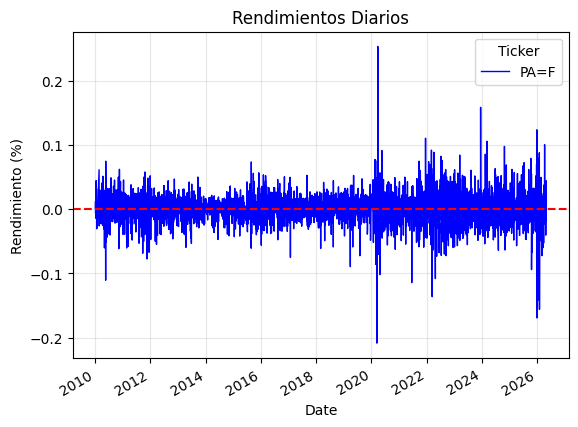

In [3]:
"""
Ahora, se nos pide calcular los rendimientos, el sesgo y la curtosis
"""
#Rendimiento 
from Funciones_Creadas import rendimientos
rendimientos_diarios = rendimientos(data)
print(rendimientos_diarios)

#Curtosis 
from Funciones_Creadas import curtosis
k= curtosis(rendimientos_diarios)
print(f"El valor de la curtosis es de:")
print(k)

#Vamos a hacer el analisis de la Curtosis
if k > 3:
    print("Los datos siguen una distribución leptucurtica, es decir, tiene una" 
          " menor concentración en la mediana y tiene colas pesadas")
if k < 3:
    print("Los datos siguen una distribución platicurtica, es decir, hay una"
          " mayor concentración en la mediana y tiene colas ligeras")
if k == 3:
    print("La distribución de los datos parece indicar una distribución normal")

#Sesgo
from Funciones_Creadas import sesgo
s = sesgo(rendimientos_diarios)
print("El sesgo es de:")
print(s)

#Analisis del Sesgo
if s > 0:
    print("Esto nos indica que la cola derecha es más larga y más pesada que "
          "la izquierda.")
if s < 0:
    print("Esto nos indica que la cola izquierda es más larga y más pesada que "
          "la derecha.")
if s == 0:
    print("Los datos no tienden a inclinarse ni a la derecha ni a la izquierda")

#Teniendo los datos anteriores, vamos a graficar los rendimientos.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
rendimientos_diarios.plot(color='blue', linewidth=1)
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Rendimientos Diarios')
plt.ylabel('Rendimiento (%)')
plt.grid(True, alpha=0.3)
plt.show()


3. Calcula el VaR y ES para la serie completa de datos a los siguientes intervalos de confianza: α = 0,95, 0,975, y 0,99 bajo una aproximación paramétrica asumiendo una distribución normal y t-student, además bajo una aproximación histórica y Monte Carlo. Muestra tus resultados en una tabla en el reporte.

In [4]:
"""
Ahora hay que calcular el VaR (Value at Risk) y ES (Espected Shortfall) para los siguientes alpha's
α = 0.95
α = 0.975
α = 0.99
"""
from scipy import stats
from scipy.stats import t
from Funciones_Creadas import Value_at_Risk
from Funciones_Creadas import Expected_Shortfall
#Aproximación Parametrica
print("Aproximación Parametrica")

#Asumamos que primero se trata de una Distribución Normal
print("Value-at-Risk")
print("Distribución Normal")
mu, sigma = stats.norm.fit(rendimientos_diarios) #Esto para encontrar los parametros para la normal


#Al 95%
print("El Value at Risk al 95% asumiendo que los datos se"
      " distribuyen normal es de:")
print(stats.norm.ppf(0.05, mu, sigma)) #Ya es el cuantil

#Al 97.5%
print("El Value at Risk al 97.5% asumiendo que los datos se"
      " distribuyen normal es de:")
print(stats.norm.ppf(0.025, mu, sigma))

#Al 99%
print("El Value at Risk al 95% asumiendo que los datos se"
      " distribuyen normal es de:")
print(stats.norm.ppf(0.01, mu, sigma))


#%% Aquí ya es lo del Expected Shortfall
print("Expected Shortfall")
#Ahora calculemos el Expected Shortfall
#Antes voy a tener que crear una función que me ayude a calcular el Expected Shortfall

from Funciones_Creadas import Expected_Shortfall_normal

#ES 95%
print("El Expected Shortfall al 95% asumiendo que los datos se"
      " distribuyen normal es:")
print(Expected_Shortfall_normal(0.05, mu, sigma))

#ES 97.5%
print("El Expected Shortfall al 97.5% asumiendo que los datos se"
      " distribuyen normal es:")
print(Expected_Shortfall_normal(0.025, mu, sigma))

#ES 99%
print("El Expected Shortfall al 99% asumiendo que los datos se"
      " distribuyen normal es:")
print(Expected_Shortfall_normal(0.01, mu, sigma))

###################################################################################################################
from Funciones_Creadas import Expected_Shortfall_tstudent
print("-"*50)
#Ahora asumamos que se trata de una Distribución T-Student
print("Con distribución t-student")

#Primero vamos con el VaR
df, loc, scale = stats.t.fit(rendimientos_diarios)
#Al 95%
print("El Value at Risk al 95%  asumiendo que los datos se"
      " distribuyen t-student es de:")
print((stats.t.ppf(.05,df,loc,scale)))

#Al 97.5%
print("El Value at Risk al 97.5%  asumiendo que los datos se"
      " distribuyen t-student es de:")
print((stats.t.ppf(.025,df,loc,scale)))

#Al 99%
print("El Value at Risk al 95% asumiendo que los datos se"
      " distribuyen t-student es de:")
print((stats.t.ppf(.01,df,loc,scale)))

#Ahora vamos con el ES

#ES 95%
print("El Expected Shortfall usando la distribución t-student al 95% es de:")
E11 = Expected_Shortfall_tstudent(0.05, df, loc, scale)
print(E11)

#ES 97.5%
print("El Expected Shortfall usando la distribución t-student al 97.5% es de:")
E12 = Expected_Shortfall_tstudent(0.025, df, loc, scale)
print(E12)

#ES 99%
print("El Expected Shortfall usando la distribución t-student al 99% es de:")
E13 = Expected_Shortfall_tstudent(0.01, df, loc, scale)
print(E13)


Aproximación Parametrica
Value-at-Risk
Distribución Normal
El Value at Risk al 95% asumiendo que los datos se distribuyen normal es de:
-0.0378240374253619
El Value at Risk al 97.5% asumiendo que los datos se distribuyen normal es de:
-0.04518345447877286
El Value at Risk al 95% asumiendo que los datos se distribuyen normal es de:
-0.053740367254098365
Expected Shortfall
El Expected Shortfall al 95% asumiendo que los datos se distribuyen normal es:
-0.04758315801676717
El Expected Shortfall al 97.5% asumiendo que los datos se distribuyen normal es:
-0.054007897400366704
El Expected Shortfall al 99% asumiendo que los datos se distribuyen normal es:
-0.06165460652858106
--------------------------------------------------
Con distribución t-student
El Value at Risk al 95%  asumiendo que los datos se distribuyen t-student es de:
-0.03429770222095483
El Value at Risk al 97.5%  asumiendo que los datos se distribuyen t-student es de:
-0.04477552221188345
El Value at Risk al 95% asumiendo que l

In [5]:
#Aproximación Historica
from Funciones_Creadas import Value_at_Risk
from Funciones_Creadas import Expected_Shortfall
#VaR
# VaR 95%
print("El VaR Historico al 95% es de:")
print(Value_at_Risk(rendimientos_diarios, .05))
# VaR 97.5%
print("El VaR Historico al 95% es de:")
print(Value_at_Risk(rendimientos_diarios, .025))
# VaR 99%
print("El VaR Historico al 95% es de:")
print(Value_at_Risk(rendimientos_diarios, .01))

#CVaR
#CVaR 95%
print("El CVaR Historico al 95% es de:")
print(Expected_Shortfall(rendimientos_diarios,.05))

#CVaR 97.5%
print("El CVaR Historico al 97.5% es de:")
print(Expected_Shortfall(rendimientos_diarios,.025))

#CVaR 99%
print("El CVaR Historico al 99% es de:")
print(Expected_Shortfall(rendimientos_diarios,.01))






El VaR Historico al 95% es de:
0.03536864079250761
El VaR Historico al 95% es de:
0.045780116156865086
El VaR Historico al 95% es de:
0.05936702308060321
El CVaR Historico al 95% es de:
Ticker
PA=F   -0.002155
dtype: float64
El CVaR Historico al 97.5% es de:
Ticker
PA=F   -0.001072
dtype: float64
El CVaR Historico al 99% es de:
Ticker
PA=F   -0.000269
dtype: float64


In [6]:
#Ahora hagamos el metodo Monte Carlo

N = 10000  # número de simulaciones

# Simulación normal
sim_normal = np.random.normal(mu, sigma, N)

# Simulación t-student
sim_t = t.rvs(df, loc=loc, scale=scale, size=N)

# Convertir a DataFrame para reutilizar tus funciones
sim_normal = pd.DataFrame(sim_normal, columns=["Close"])
sim_t = pd.DataFrame(sim_t, columns=["Close"])

# CALCULAR VaR y ES
resultados_mc = []

for alpha in [0.95, 0.975, 0.99]:

    # Normal MC
    var_mc_norm = Value_at_Risk(sim_normal.rename(columns={"Close":"Close"}), alpha)
    es_mc_norm = Expected_Shortfall(sim_normal["Close"], alpha)

    # t-Student MC
    var_mc_t = Value_at_Risk(sim_t.rename(columns={"Close":"Close"}), alpha)
    es_mc_t = Expected_Shortfall(sim_t["Close"], alpha)

    resultados_mc.append([
        alpha,
        var_mc_norm, es_mc_norm,
        var_mc_t, es_mc_t
    ])

# Tabla
tabla_mc = pd.DataFrame(resultados_mc, columns=[
    "Alpha",
    "VaR MC Normal", "ES MC Normal",
    "VaR MC t", "ES MC t"
])

print(tabla_mc)

   Alpha  VaR MC Normal  ES MC Normal  VaR MC t   ES MC t
0  0.950      -0.038067     -0.047766 -0.034624 -0.052529
1  0.975      -0.044629     -0.054437 -0.044379 -0.066202
2  0.990      -0.053677     -0.063319 -0.059297 -0.090033


4. En el mercado, el VaR y el ES son las medidas populares para medir el riesgo de una cartera o un activo, sin embargo, es común ver que usan rolling windows, i.e. fijar una ventana de X d ́ıas y con esos datos calcular el VaR o ES del d ́ıa X + 1, ejemplo: con una ventana de 252 retornos (r1, r2, ..., r252) calculas el V aRα asociado al retorno 253, ahora el V aRα asociado al retorno 254 viene del conjunto de datos (r2, r3, ..., r253), etc. Con esto en mente en una sola gr ́afica muestra las ganancias y p ́erdidas además del VaR y el ES con α = 0,95 y 0,99 con una rolling window de 252 retornos (debe de ser una serie de tiempo) y sobre todo recuerda que el V aRt α es calculado con los retornos r1, r2, ..., r252 y busca predecir el retorno r253, y el V aRt+1. α calculado con los retornos r2, r3, ..., r253 busca predecir el retorno r254, etc. La estimación del VaR y ES debe de ser histórico y paramétrico (puedes asumir una distribución normal por practicidad), recuerda el ejemplo que se vio en clase.

[*********************100%***********************]  1 of 1 completed

Tabla Rolling Windows VaR (Parametrico)
            95% VaR Rolling  99% VaR Rolling
Date                                        
2026-04-27            -5.50            -7.88
2026-04-28            -5.50            -7.87
2026-04-29            -5.50            -7.88
2026-04-30            -5.49            -7.87
2026-05-01            -5.49            -7.87
Las predicción para el VaR con alpha = .05 para 253 es:
-0.03695898916081967
La predicción para el VaR con alpha =.01 para 253 es:
-0.053460766357783164
############################################################
Tabla Rolling Windows CVaR (Parametrico)
            95% CVaR Rolling  99% CVaR Rolling
Date                                          
2026-04-27             -6.96             -9.06
2026-04-28             -6.95             -9.05
2026-04-29             -6.96             -9.06
2026-04-30             -6.95             -9.06
2026-05-01             -6.95             -9.06
La predicción para el CVaR para el día 253 con alpha = .05 es

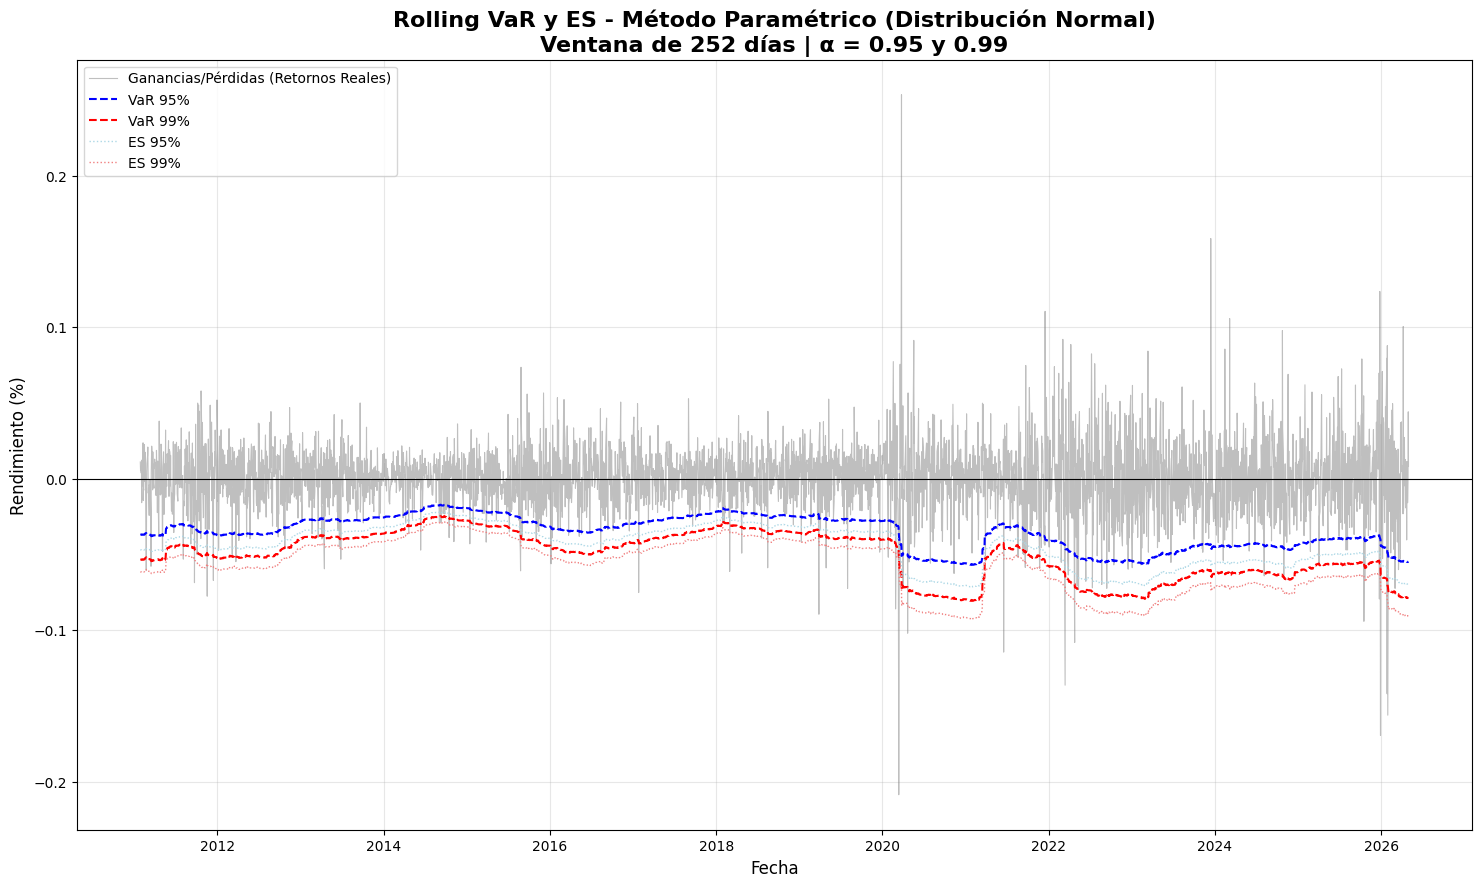

In [7]:
"""
Comenzamos con el metodo parametrico
"""
import pandas as pd

#Primero hay que traer nuevamente los retornos pero sin contar los ultimos 252 días
df = yf.download('PA=F', start = "2010-01-01")['Close']
retornos = df.pct_change().dropna()

#Se asumira que la distribución Normal
rolling_mean = retornos.rolling(window = 252).mean ()
rolling_std = retornos.rolling(window = 252).std()

#Comenzamos con el VaR
#Con alpha = .05

VaR_95 = norm.ppf(1-.95, rolling_mean, rolling_std)
VaR_95_Porcentaje = (VaR_95 *100).round(2)

#Con alpha =.01

VaR_99 =norm.ppf(1-.99, rolling_mean, rolling_std)
VaR_99_Porcentaje = (VaR_99 * 100).round(2)

#Vamos con Expected Shortfall

#Con alpha = .05
CVaR_95 = Expected_Shortfall_normal(.05,rolling_mean, rolling_std)
CVaR_95_Porcentaje = (CVaR_95*100).round(2)

#Con alpha = .01
CVaR_99 = Expected_Shortfall_normal(.01,rolling_mean, rolling_std)
CVaR_99_Porcentaje = (CVaR_99*100).round(2)

#Vamos a verlo en una tablita para que podemos comparar
print("Tabla Rolling Windows VaR (Parametrico)")
VaR_df = pd.DataFrame({'Date':retornos.index, '95% VaR Rolling': VaR_95_Porcentaje.squeeze(), '99% VaR Rolling': VaR_99_Porcentaje.squeeze()})
VaR_df.set_index('Date', inplace = True)

print(VaR_df.tail())

#Predicción para el VaR
#Para predecir los valores, vamos a tener que cambiar algunas cosas

# Aplanar el array de 2D a 1D
VaR_95_1d = VaR_95.ravel()  # o VaR_95.flatten()
VaR_99_1d = VaR_99.ravel()

#Se crea la serie de tiempo
VaR_95_Serie = pd.Series(VaR_95_1d, index = retornos.index)
VaR_99_Serie = pd.Series(VaR_99_1d, index = retornos.index)
VaR_95_Predi = VaR_95_Serie.shift(1)
VaR_99_Predi = VaR_99_Serie.shift(1)

print("Las predicción para el VaR con alpha = .05 para 253 es:")
print(VaR_95_Predi.iloc[252])

print("La predicción para el VaR con alpha =.01 para 253 es:")
print(VaR_99_Predi.iloc[252])


#Tabla del Expected Shortfall
print("#"*60)
print("Tabla Rolling Windows CVaR (Parametrico)")
CVaR_df = pd.DataFrame({'Date':retornos.index, '95% CVaR Rolling': CVaR_95_Porcentaje.squeeze(), '99% CVaR Rolling': CVaR_99_Porcentaje.squeeze()})
CVaR_df.set_index('Date', inplace = True)

print(CVaR_df.tail())

#Predicciones para el CVaR
# Aplanar el array de 2D a 1D, porque así solito no te deja
CVaR_95_1d = CVaR_95.values.ravel()
CVaR_99_1d = CVaR_99.values.ravel()

#Se crea la serie de tiempo
CVaR_95_Serie = pd.Series(CVaR_95_1d, index = retornos.index)
CVaR_99_Serie = pd.Series(CVaR_99_1d, index = retornos.index)
CVaR_95_Predi = CVaR_95_Serie.shift(1)
CVaR_99_Predi = CVaR_99_Serie.shift(1)

print("La predicción para el CVaR para el día 253 con alpha = .05 es de:")
print(CVaR_95_Predi.iloc[253])

print("La predicción para el CVaR para el día 253 con alpha = .01 es de:")
print(CVaR_99_Predi.iloc[253])

# Grafica para el metodo Parametrico

 
window = 252
fechas_pred = retornos.index[252:]  # Desde día 253 en adelante
retornos_reales = retornos.iloc[252:]  # Retornos reales desde día 253

VaR_95_grafica = VaR_95_Predi.iloc[252:].values
VaR_99_grafica = VaR_99_Predi.iloc[252:].values
CVaR_95_grafica = CVaR_95_Predi.iloc[252:].values
CVaR_99_grafica = CVaR_99_Predi.iloc[252:].values

plt.figure(figsize=(18, 10))

plt.plot(fechas_pred, retornos_reales, 
         label='Ganancias/Pérdidas (Retornos Reales)', 
         color='gray', alpha=0.5, linewidth=0.8)

plt.plot(fechas_pred, VaR_95_grafica, 
         label='VaR 95%', color='blue', linewidth=1.5, linestyle='--')

plt.plot(fechas_pred, VaR_99_grafica, 
         label='VaR 99%', color='red', linewidth=1.5, linestyle='--')

plt.plot(fechas_pred, CVaR_95_grafica, 
         label='ES 95%', color='lightblue', linewidth=1, linestyle=':')

plt.plot(fechas_pred, CVaR_99_grafica, 
         label='ES 99%', color='lightcoral', linewidth=1, linestyle=':')

plt.title(f'Rolling VaR y ES - Método Paramétrico (Distribución Normal)\nVentana de {window} días | α = 0.95 y 0.99', 
          fontsize=16, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rendimiento (%)', fontsize=12)
plt.legend(loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.8)

[*********************100%***********************]  1 of 1 completed


Dataframe creado


c:\Users\thine\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)
c:\Users\thine\AppData\Local\Programs\Python\Python312\Lib\site-packages\matplotlib\cbook.py:1398: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return np.asarray(x, float)


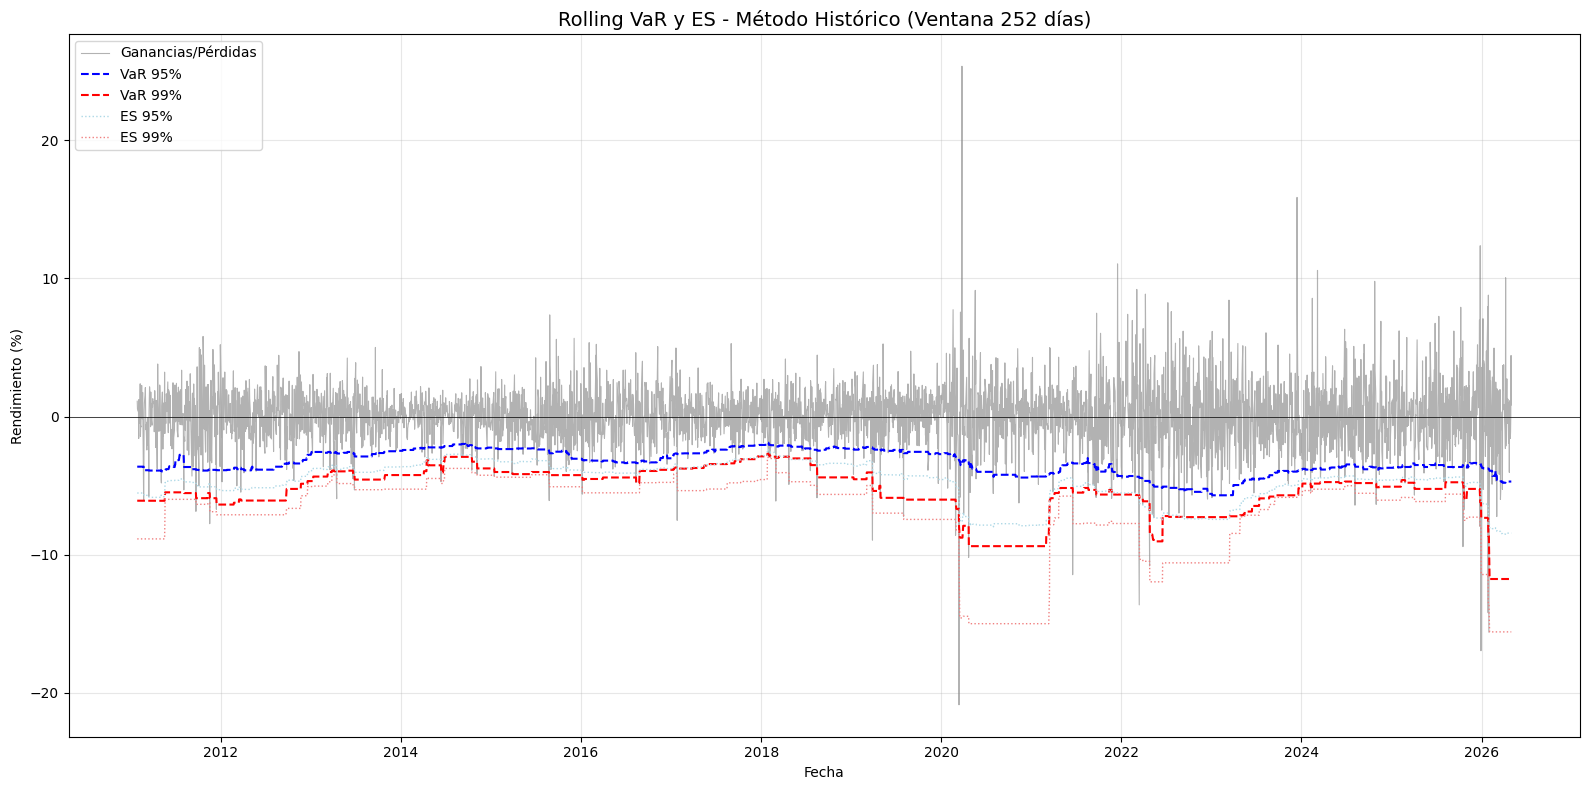

PREDICCIÓN PARA EL DÍA 253
Fecha: 2011-01-27 00:00:00
Retorno Real: 1.1088%
VaR 95%: -3.6278%
VaR 99%: -6.0914%
ES 95%:  -5.5348%
ES 99%:  -8.8556%


C:\Users\thine\AppData\Local\Temp\ipykernel_38208\167455645.py:70: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  es95_253 = float(pred_253['ES_95%']) if hasattr(pred_253['ES_95%'], '__float__') else pred_253['ES_95%']
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\167455645.py:71: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  es99_253 = float(pred_253['ES_99%']) if hasattr(pred_253['ES_99%'], '__float__') else pred_253['ES_99%']


In [8]:
#Ahora vamos con el VaR Historico
# Volvemos a descargar los datos
df = yf.download("PA=F", start="2010-01-01")['Close']
retornos = df.pct_change().dropna() * 100
window = 252 #Ventana de días a tomar (Esto nos lo da el ejercicio)

#Hay que manejar los datos como arreglos
VaR_95 = []
VaR_99 = []
ES_95 = []
ES_99 = []
fechas = []

for i in range(window, len(retornos)):
    ventana = retornos.iloc[i-window:i]
    
    var_95 = np.percentile(ventana, 5)
    var_99 = np.percentile(ventana, 1)
    es_95 = ventana[ventana <= var_95].mean()
    es_99 = ventana[ventana <= var_99].mean()
    
    VaR_95.append(var_95)
    VaR_99.append(var_99)
    ES_95.append(es_95)
    ES_99.append(es_99)
    fechas.append(retornos.index[i])

# Creamos el DataFrame
resultados = pd.DataFrame()
resultados['Fecha'] = fechas
resultados['Retorno_Real'] = retornos.iloc[window:].values[:len(fechas)]
resultados['VaR_95%'] = VaR_95
resultados['VaR_99%'] = VaR_99
resultados['ES_95%'] = ES_95
resultados['ES_99%'] = ES_99

print("Dataframe creado")

# Graficamos
plt.figure(figsize=(16, 8))

plt.plot(resultados['Fecha'], resultados['Retorno_Real'],label='Ganancias/Pérdidas', color='gray', alpha=0.6, linewidth=0.8)

plt.plot(resultados['Fecha'], resultados['VaR_95%'],label='VaR 95%', color='blue', linewidth=1.5, linestyle='--')

plt.plot(resultados['Fecha'], resultados['VaR_99%'],label='VaR 99%', color='red', linewidth=1.5, linestyle='--')

plt.plot(resultados['Fecha'], resultados['ES_95%'],label='ES 95%', color='lightblue', linewidth=1, linestyle=':')

plt.plot(resultados['Fecha'], resultados['ES_99%'],label='ES 99%', color='lightcoral', linewidth=1, linestyle=':')

plt.title(f'Rolling VaR y ES - Método Histórico (Ventana {window} días)', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Rendimiento (%)')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Mostramos las predicciones para el día 253
print("PREDICCIÓN PARA EL DÍA 253")

pred_253 = resultados.iloc[0] # Use .iloc[0] y asegurar que son números
fecha_253 = pred_253['Fecha']
retorno_253 = float(pred_253['Retorno_Real']) if hasattr(pred_253['Retorno_Real'], '__float__') else pred_253['Retorno_Real']
var95_253 = float(pred_253['VaR_95%']) if hasattr(pred_253['VaR_95%'], '__float__') else pred_253['VaR_95%']
var99_253 = float(pred_253['VaR_99%']) if hasattr(pred_253['VaR_99%'], '__float__') else pred_253['VaR_99%']
es95_253 = float(pred_253['ES_95%']) if hasattr(pred_253['ES_95%'], '__float__') else pred_253['ES_95%']
es99_253 = float(pred_253['ES_99%']) if hasattr(pred_253['ES_99%'], '__float__') else pred_253['ES_99%']

print(f"Fecha: {fecha_253}")
print(f"Retorno Real: {retorno_253:.4f}%")
print(f"VaR 95%: {var95_253:.4f}%")
print(f"VaR 99%: {var99_253:.4f}%")
print(f"ES 95%:  {es95_253:.4f}%")
print(f"ES 99%:  {es99_253:.4f}%")

5. Finalmente, para saber la eficiencia de nuestras estimaciones calcularemos el numero de veces que la perdida fue superior a la estimacion usando Var o ES, i.e. Definiremos violacion si r253 < V aRtα o EStα donde el V aRtα o EStα fue calculado con los retornos r1, r2, ..., r252, o si r254 < V aRt
α o EStα donde el V aRtα o EStα fue calculado con los retornos r2, r3, ..., r253, etc. En una tabla reporta el numero de violaciones y como porcentaje del tamaño de la muestra para cada nivel de confianza y cada medida de riesgo.

In [9]:

#Volvemos a descargar los datos
df = yf.download('PA=F', start="2010-01-01")['Close']
retornos = df.pct_change().dropna() * 100

def calcular_VaR_ES_historico(ventana):
    """Calcula VaR y ES histórico para una ventana"""
    var_95 = np.percentile(ventana, 5)
    var_99 = np.percentile(ventana, 1)
    es_95 = ventana[ventana <= var_95].mean()
    es_99 = ventana[ventana <= var_99].mean()
    return var_95, var_99, es_95, es_99

def calcular_VaR_ES_normal(ventana):
    """Calcula VaR y ES paramétrico (normal) para una ventana"""
    mu = ventana.mean()
    sigma = ventana.std()
    var_95 = norm.ppf(0.05, mu, sigma)
    var_99 = norm.ppf(0.01, mu, sigma)
    
    z_95 = norm.ppf(0.05)
    z_99 = norm.ppf(0.01)
    es_95 = mu - sigma * (norm.pdf(z_95) / 0.05)
    es_99 = mu - sigma * (norm.pdf(z_99) / 0.01)
    
    return var_95, var_99, es_95, es_99

# ROLLING WINDOW PARA AMBOS MÉTODOS
window = 252
resultados_historico = []
resultados_normal = []

for i in range(window, len(retornos)):
    ventana = retornos.iloc[i-window:i]
    retorno_real = retornos.iloc[i]
    fecha = retornos.index[i]
    
    # Método Histórico
    var95_h, var99_h, es95_h, es99_h = calcular_VaR_ES_historico(ventana)
    
    # Método Paramétrico (Normal)
    var95_n, var99_n, es95_n, es99_n = calcular_VaR_ES_normal(ventana)
    
    # Guardar resultados
    resultados_historico.append({
        'Fecha': fecha,
        'Retorno_Real': retorno_real,
        'VaR_95': var95_h,
        'VaR_99': var99_h,
        'ES_95': es95_h,
        'ES_99': es99_h,
        'Violacion_VaR_95': retorno_real < var95_h,
        'Violacion_VaR_99': retorno_real < var99_h,
        'Violacion_ES_95': retorno_real < es95_h,
        'Violacion_ES_99': retorno_real < es99_h
    })
    
    resultados_normal.append({
        'Fecha': fecha,
        'Retorno_Real': retorno_real,
        'VaR_95': var95_n,
        'VaR_99': var99_n,
        'ES_95': es95_n,
        'ES_99': es99_n,
        'Violacion_VaR_95': retorno_real < var95_n,
        'Violacion_VaR_99': retorno_real < var99_n,
        'Violacion_ES_95': retorno_real < es95_n,
        'Violacion_ES_99': retorno_real < es99_n
    })

df_historico = pd.DataFrame(resultados_historico)
df_normal = pd.DataFrame(resultados_normal)

print(f"Las predicciones son: {len(df_historico)}")

# TABLA DE VIOLACIONES

def tabla_violaciones(df, nombre_metodo):
    """Calcula y muestra las violaciones para un método"""
    total = len(df)
    
    violaciones = {
        'Métrica': ['VaR 95%', 'VaR 99%', 'ES 95%', 'ES 99%'],
        'Violaciones': [
            df['Violacion_VaR_95'].sum(),
            df['Violacion_VaR_99'].sum(),
            df['Violacion_ES_95'].sum(),
            df['Violacion_ES_99'].sum()
        ],
        'Porcentaje (%)': [
            df['Violacion_VaR_95'].sum() / total * 100,
            df['Violacion_VaR_99'].sum() / total * 100,
            df['Violacion_ES_95'].sum() / total * 100,
            df['Violacion_ES_99'].sum() / total * 100
        ],
        'Esperado (%)': [5, 1, 5, 1]
    }
    
    return pd.DataFrame(violaciones)

print("TABLA DE VIOLACIONES - MÉTODO HISTÓRICO")
tabla_hist = tabla_violaciones(df_historico, "Histórico")
print(tabla_hist.round(2).to_string(index=False))

print("TABLA DE VIOLACIONES - MÉTODO PARAMÉTRICO (NORMAL)")
tabla_norm = tabla_violaciones(df_normal, "Paramétrico")
print(tabla_norm.round(2).to_string(index=False))

#Vamos a comparar los metodos
print("COMPARACIÓN DE EFICIENCIA ENTRE MÉTODOS")

comparacion = pd.DataFrame({
    'Métrica': ['VaR 95%', 'VaR 99%', 'ES 95%', 'ES 99%'],
    'Histórico_%': [
        df_historico['Violacion_VaR_95'].mean() * 100,
        df_historico['Violacion_VaR_99'].mean() * 100,
        df_historico['Violacion_ES_95'].mean() * 100,
        df_historico['Violacion_ES_99'].mean() * 100
    ],
    'Paramétrico_%': [
        df_normal['Violacion_VaR_95'].mean() * 100,
        df_normal['Violacion_VaR_99'].mean() * 100,
        df_normal['Violacion_ES_95'].mean() * 100,
        df_normal['Violacion_ES_99'].mean() * 100
    ],
    'Esperado_%': [5, 1, 5, 1]
})

print(comparacion.round(2).to_string(index=False))

#Se analiza la eficiencia
print("ANÁLISIS DE EFICIENCIA")

for metrica in ['VaR_95', 'VaR_99', 'ES_95', 'ES_99']:
    viol_hist = df_historico[f'Violacion_{metrica}'].mean() * 100
    viol_norm = df_normal[f'Violacion_{metrica}'].mean() * 100
    
    if metrica == 'VaR_95':
        esperado = 5
        nombre = "VaR 95%"
    elif metrica == 'VaR_99':
        esperado = 1
        nombre = "VaR 99%"
    elif metrica == 'ES_95':
        esperado = 5
        nombre = "ES 95%"
    else:
        esperado = 1
        nombre = "ES 99%"
    
    print(f" {nombre}:")
    print(f"   Histórico:   {viol_hist:.2f}% (Esperado: {esperado}%) - {' Bueno' if abs(viol_hist - esperado) <= 1 else ' Desviado'}")
    print(f"   Paramétrico: {viol_norm:.2f}% (Esperado: {esperado}%) - {' Bueno' if abs(viol_norm - esperado) <= 1 else ' Desviado'}")

#  TABLA COMPLETA (con números)
print("Resumen completo de las violaciones")

resumen = pd.DataFrame({
    'Métrica': ['VaR 95%', 'VaR 95%', 'VaR 99%', 'VaR 99%', 'ES 95%', 'ES 95%', 'ES 99%', 'ES 99%'],
    'Método': ['Histórico', 'Paramétrico', 'Histórico', 'Paramétrico', 'Histórico', 'Paramétrico', 'Histórico', 'Paramétrico'],
    'Violaciones': [
        df_historico['Violacion_VaR_95'].sum(),
        df_normal['Violacion_VaR_95'].sum(),
        df_historico['Violacion_VaR_99'].sum(),
        df_normal['Violacion_VaR_99'].sum(),
        df_historico['Violacion_ES_95'].sum(),
        df_normal['Violacion_ES_95'].sum(),
        df_historico['Violacion_ES_99'].sum(),
        df_normal['Violacion_ES_99'].sum()
    ],
    'Porcentaje': [
        df_historico['Violacion_VaR_95'].mean() * 100,
        df_normal['Violacion_VaR_95'].mean() * 100,
        df_historico['Violacion_VaR_99'].mean() * 100,
        df_normal['Violacion_VaR_99'].mean() * 100,
        df_historico['Violacion_ES_95'].mean() * 100,
        df_normal['Violacion_ES_95'].mean() * 100,
        df_historico['Violacion_ES_99'].mean() * 100,
        df_normal['Violacion_ES_99'].mean() * 100
    ],
    'Esperado': [5, 5, 1, 1, 5, 5, 1, 1]
})

print(resumen.round(2).to_string(index=False))

# Determinar qué método es mejor
var95_hist_error = abs(df_historico['Violacion_VaR_95'].mean() * 100 - 5)
var95_norm_error = abs(df_normal['Violacion_VaR_95'].mean() * 100 - 5)

if var95_hist_error < var95_norm_error:
    print(" Para VaR 95%, el método HISTÓRICO es más preciso")
else:
    print(" Para VaR 95%, el método PARAMÉTRICO es más preciso")

var99_hist_error = abs(df_historico['Violacion_VaR_99'].mean() * 100 - 1)
var99_norm_error = abs(df_normal['Violacion_VaR_99'].mean() * 100 - 1)

if var99_hist_error < var99_norm_error:
    print("Para VaR 99%, el método HISTÓRICO es más preciso")
else:
    print("Para VaR 99%, el método PARAMÉTRICO es más preciso")

[*********************100%***********************]  1 of 1 completed


Las predicciones son: 3835
TABLA DE VIOLACIONES - MÉTODO HISTÓRICO
Métrica                     Violaciones                         Porcentaje (%)  Esperado (%)
VaR 95% Ticker
PA=F    True
dtype: bool Ticker
PA=F    0.026076
dtype: float64             5
VaR 99% Ticker
PA=F    True
dtype: bool Ticker
PA=F    0.026076
dtype: float64             1
 ES 95% Ticker
PA=F    True
dtype: bool Ticker
PA=F    0.026076
dtype: float64             5
 ES 99% Ticker
PA=F    True
dtype: bool Ticker
PA=F    0.026076
dtype: float64             1
TABLA DE VIOLACIONES - MÉTODO PARAMÉTRICO (NORMAL)
Métrica                     Violaciones                         Porcentaje (%)  Esperado (%)
VaR 95% Ticker
PA=F    True
dtype: bool Ticker
PA=F    0.026076
dtype: float64             5
VaR 99% Ticker
PA=F    True
dtype: bool Ticker
PA=F    0.026076
dtype: float64             1
 ES 95% Ticker
PA=F    True
dtype: bool Ticker
PA=F    0.026076
dtype: float64             5
 ES 99% Ticker
PA=F    True
dtype: bool Ticke

C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:114: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_historico['Violacion_VaR_95'].mean() * 100,
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:115: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_historico['Violacion_VaR_99'].mean() * 100,
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:116: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_historico['Violacion_ES_95'].mean() * 100,
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:117: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_histo

Métrica  Histórico_%  Paramétrico_%  Esperado_%
VaR 95%         0.03           0.03           5
VaR 99%         0.03           0.03           1
 ES 95%         0.03           0.03           5
 ES 99%         0.03           0.03           1
ANÁLISIS DE EFICIENCIA


C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:134: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  viol_hist = df_historico[f'Violacion_{metrica}'].mean() * 100
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:135: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  viol_norm = df_normal[f'Violacion_{metrica}'].mean() * 100


...

C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:171: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_historico['Violacion_VaR_95'].mean() * 100,
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:172: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_normal['Violacion_VaR_95'].mean() * 100,
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:173: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_historico['Violacion_VaR_99'].mean() * 100,
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:174: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  df_normal[

Métrica      Método                     Violaciones  Porcentaje  Esperado
VaR 95%   Histórico Ticker
PA=F    True
dtype: bool        0.03         5
VaR 95% Paramétrico Ticker
PA=F    True
dtype: bool        0.03         5
VaR 99%   Histórico Ticker
PA=F    True
dtype: bool        0.03         1
VaR 99% Paramétrico Ticker
PA=F    True
dtype: bool        0.03         1
 ES 95%   Histórico Ticker
PA=F    True
dtype: bool        0.03         5
 ES 95% Paramétrico Ticker
PA=F    True
dtype: bool        0.03         5
 ES 99%   Histórico Ticker
PA=F    True
dtype: bool        0.03         1
 ES 99% Paramétrico Ticker
PA=F    True
dtype: bool        0.03         1


C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:186: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  var95_hist_error = abs(df_historico['Violacion_VaR_95'].mean() * 100 - 5)
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:187: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  var95_norm_error = abs(df_normal['Violacion_VaR_95'].mean() * 100 - 5)


 Para VaR 95%, el método PARAMÉTRICO es más preciso
Para VaR 99%, el método PARAMÉTRICO es más preciso


C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:194: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  var99_hist_error = abs(df_historico['Violacion_VaR_99'].mean() * 100 - 1)
C:\Users\thine\AppData\Local\Temp\ipykernel_38208\951825060.py:195: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  var99_norm_error = abs(df_normal['Violacion_VaR_99'].mean() * 100 - 1)


6. En esta pregunta se estimará el VaR con una volatilidad móvil y asumiendo una distribucion normal a traves de la siguiente formula: V aR1−α = qα × σ252t, donde qα es el percentil asociado a una distribucion normal con α como nivel de significancia y los siguientes valores α = 0,05 y α = 0,01, y σ252t, es la desviacion estandar de una ventana de 252 retornos.

    Utilizando la misma logica del rolling windows calcula el VaR para ambos niveles de significancia, grafica tus resultado como en la pregunta anterior y muestra la eficiencia de esta aproximacion calculando el numero de violaciones como en la pregunta anterior.

Descargando datos del Paladio (PA=F)...


[*********************100%***********************]  1 of 1 completed


Datos cargados: 4087 días
Periodo: 2010-01-05 00:00:00 hasta 2026-05-01 00:00:00
Percentiles:
   q_95 (α=0.05): 1.6449
   q_99 (α=0.01): 2.3263
Calculando volatilidad móvil y VaR...
Predicciones 3835
Tabla de Violaciones - VaR con Volatilidad Móvil
Métrica  Violaciones  Porcentaje (%)  Esperado (%)
VaR 95%          187            4.88             5
VaR 99%           61            1.59             1


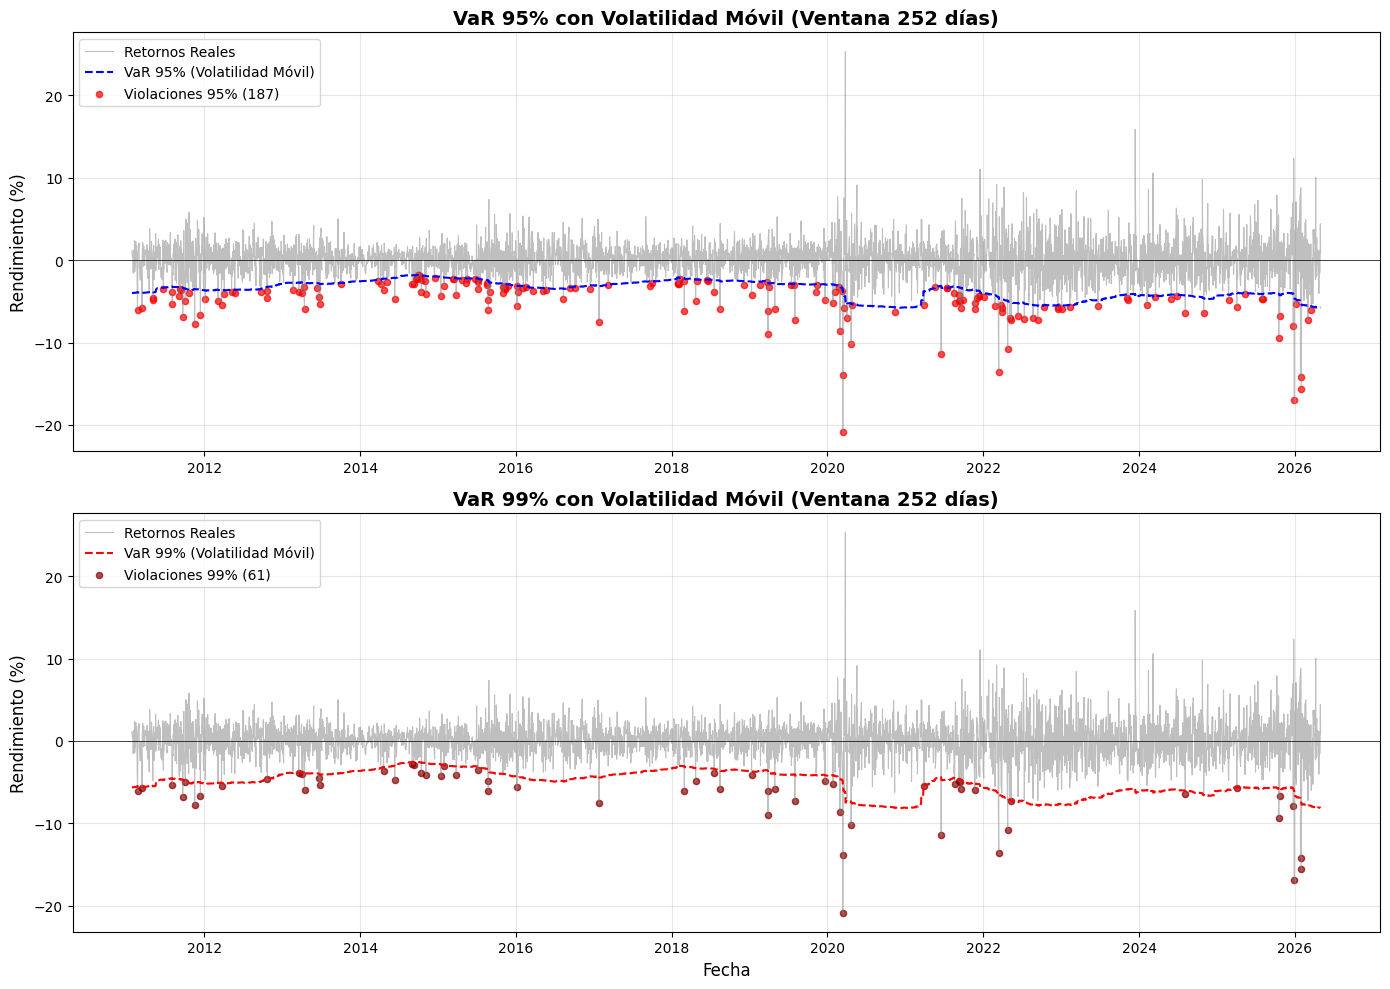

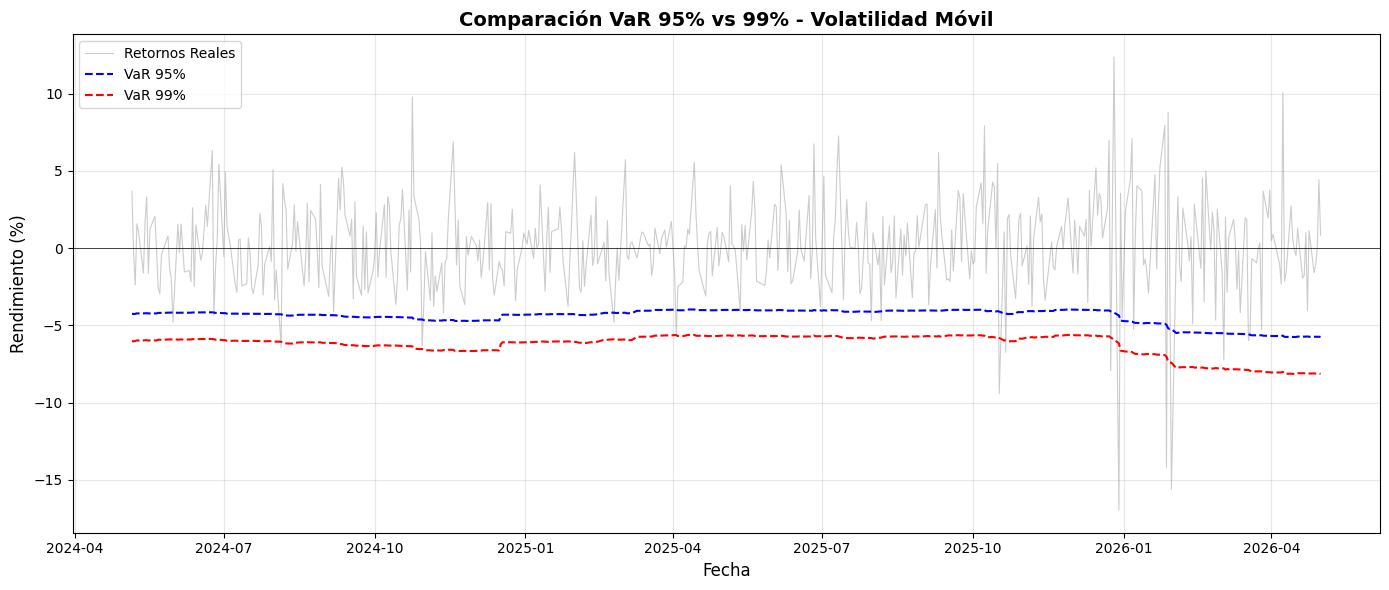

ANÁLISIS DE EFICIENCIA
 VaR 95%:
   Violaciones: 187 de 3835 días (4.88%)
   Esperado: 5%
   Diferencia: 0.12 puntos porcentuales
   Evaluación: Excelente
VaR 99%:
   Violaciones: 61 de 3835 días (1.59%)
   Esperado: 1%
   Diferencia: 0.59 puntos porcentuales
   Evaluación: Deficiente
La diferencia clave es que este método NO usa la media,
solo la volatilidad móvil y el percentil normal.

q_95 = 1.6449 (para α=0.05)
q_99 = 2.3263 (para α=0.01)


In [10]:

#  Volvemos a descargar los datos
print("Descargando datos del Paladio (PA=F)...")
df = yf.download('PA=F', start="2010-01-01")['Close']
retornos = df.pct_change().dropna() * 100  # En porcentaje

print(f"Datos cargados: {len(retornos)} días")
print(f"Periodo: {retornos.index[0]} hasta {retornos.index[-1]}")

window = 252
alpha_95 = 0.05  # Para 95% de confianza
alpha_99 = 0.01  # Para 99% de confianza

# Percentiles de la distribución normal
q_95 = norm.ppf(1 - alpha_95)  # 1.6449
q_99 = norm.ppf(1 - alpha_99)  # 2.3263

print(f"Percentiles:")
print(f"   q_95 (α=0.05): {q_95:.4f}")
print(f"   q_99 (α=0.01): {q_99:.4f}")

#Para la volatilidad móvil
print("Calculando volatilidad móvil y VaR...")

# Calcular desviación estándar móvil (volatilidad)
volatilidad_movil = retornos.rolling(window=window).std()

# Calcular VaR (sin media, solo volatilidad)
VaR_95_movil = -q_95 * volatilidad_movil  # Negativo porque es pérdida
VaR_99_movil = -q_99 * volatilidad_movil

# Alinear para predicción (el VaR calculado con días 1..252 predice día 253)
VaR_95_predicho = VaR_95_movil.shift(1)
VaR_99_predicho = VaR_99_movil.shift(1)

#Aquí empezamos con el analisis de las violaciones
# Crear DataFrame con resultados
resultados = pd.DataFrame(index=retornos.index)
resultados['Retorno_Real'] = retornos
resultados['VaR_95%'] = VaR_95_predicho
resultados['VaR_99%'] = VaR_99_predicho
resultados['Violacion_95'] = retornos < VaR_95_predicho
resultados['Violacion_99'] = retornos < VaR_99_predicho

# Eliminar filas con NaN (primeros 'window' días)
resultados = resultados.dropna()

print(f"Predicciones {len(resultados)}")

# Tabla de Violaciones
print("Tabla de Violaciones - VaR con Volatilidad Móvil")

total = len(resultados)
violaciones_95 = resultados['Violacion_95'].sum()
violaciones_99 = resultados['Violacion_99'].sum()
porcentaje_95 = violaciones_95 / total * 100
porcentaje_99 = violaciones_99 / total * 100

tabla_violaciones = pd.DataFrame({
    'Métrica': ['VaR 95%', 'VaR 99%'],
    'Violaciones': [violaciones_95, violaciones_99],
    'Porcentaje (%)': [porcentaje_95, porcentaje_99],
    'Esperado (%)': [5, 1]
})

print(tabla_violaciones.round(2).to_string(index=False))


#  Grafico del VaR 95% y Retornos
plt.figure(figsize=(14, 10))

# Gráfico de VaR 95%
plt.subplot(2, 1, 1)
plt.plot(resultados.index, resultados['Retorno_Real'], 
         label='Retornos Reales', color='gray', alpha=0.5, linewidth=0.8)
plt.plot(resultados.index, resultados['VaR_95%'], 
         label='VaR 95% (Volatilidad Móvil)', color='blue', linewidth=1.5, linestyle='--')

# Marcar violaciones
violaciones_95_plot = resultados[resultados['Violacion_95']]
plt.scatter(violaciones_95_plot.index, violaciones_95_plot['Retorno_Real'], 
            color='red', s=20, alpha=0.7, label=f'Violaciones 95% ({violaciones_95})')

plt.title('VaR 95% con Volatilidad Móvil (Ventana 252 días)', fontsize=14, fontweight='bold')
plt.ylabel('Rendimiento (%)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)

# Gráfico de VaR 99%
plt.subplot(2, 1, 2)
plt.plot(resultados.index, resultados['Retorno_Real'], 
         label='Retornos Reales', color='gray', alpha=0.5, linewidth=0.8)
plt.plot(resultados.index, resultados['VaR_99%'], 
         label='VaR 99% (Volatilidad Móvil)', color='red', linewidth=1.5, linestyle='--')

# Marcar violaciones
violaciones_99_plot = resultados[resultados['Violacion_99']]
plt.scatter(violaciones_99_plot.index, violaciones_99_plot['Retorno_Real'], 
            color='darkred', s=20, alpha=0.7, label=f'Violaciones 99% ({violaciones_99})')

plt.title('VaR 99% con Volatilidad Móvil (Ventana 252 días)', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rendimiento (%)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

#Comparación VaR 95% y VaR 99% 
plt.figure(figsize=(14, 6))

# Tomar los últimos 500 días para una mejor visualización
ultimos = resultados.tail(500)

plt.plot(ultimos.index, ultimos['Retorno_Real'], 
         label='Retornos Reales', color='gray', alpha=0.4, linewidth=0.8)
plt.plot(ultimos.index, ultimos['VaR_95%'], 
         label='VaR 95%', color='blue', linewidth=1.5, linestyle='--')
plt.plot(ultimos.index, ultimos['VaR_99%'], 
         label='VaR 99%', color='red', linewidth=1.5, linestyle='--')

plt.title('Comparación VaR 95% vs 99% - Volatilidad Móvil', fontsize=14, fontweight='bold')
plt.xlabel('Fecha', fontsize=12)
plt.ylabel('Rendimiento (%)', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# Hacemos el Analisis de eficiencia
print("ANÁLISIS DE EFICIENCIA")

print(f" VaR 95%:")
print(f"   Violaciones: {violaciones_95} de {total} días ({porcentaje_95:.2f}%)")
print(f"   Esperado: 5%")
print(f"   Diferencia: {abs(porcentaje_95 - 5):.2f} puntos porcentuales")
print(f"   Evaluación: {'Excelente' if abs(porcentaje_95 - 5) <= 0.5 else 'Aceptable' if abs(porcentaje_95 - 5) <= 1 else 'Deficiente'}")

print(f"VaR 99%:")
print(f"   Violaciones: {violaciones_99} de {total} días ({porcentaje_99:.2f}%)")
print(f"   Esperado: 1%")
print(f"   Diferencia: {abs(porcentaje_99 - 1):.2f} puntos porcentuales")
print(f"   Evaluación: {'Excelente' if abs(porcentaje_99 - 1) <= 0.2 else 'Aceptable' if abs(porcentaje_99 - 1) <= 0.5 else 'Deficiente'}")


#COMPARACIÓN CON MÉTODO COMPLETO (Normal con media)"
print("La diferencia clave es que este método NO usa la media,")
print("solo la volatilidad móvil y el percentil normal.")
print(f"\nq_95 = {q_95:.4f} (para α=0.05)")
print(f"q_99 = {q_99:.4f} (para α=0.01)")
